In [1]:
import xarray as xr
import rioxarray as rioxr

import rasterio
from rasterio.transform import Affine
from rasterio.plot import show


import geopandas as geopd
import pandas as pd

import numpy as np
import numpy.ma as ma

from glob import glob

import os
import pathlib

from parallelbar import progress_map

import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"]  = 400
plt.style.use('dark_background')

from netCDF4 import Dataset

from timeseries_utils import read_daily_timeseries_csv

# This script preprocesses Singer et al 2021 potential evapotranspiration data for catchments.
# It reads climate data from NetCDF files, clips the data to the catchment geometries, and calculates the mean values for each catchment.
# The results are saved as CSV files.

In [4]:
# Path to the vector watershed file
vector_watershed_path = "/media/iielse/T9/CAMELS-FI/data/CAMELS_FI_catchment_boundaries.gpkg"
watersheds = geopd.read_file(vector_watershed_path, layer='catchments')
watersheds = watersheds.to_crs(epsg=4326)
# Root directories for data
root = '/media/iielse/T9/CAMELS-FI_pet_revision'
src_root = os.path.join(root, "raw_data")
dst_root = os.path.join(root, "extracted")


In [3]:
def mean_singer(args):
    src_path, dst_path, watersheds = args
    data = Dataset(src_path)
    pet = data.variables['pet']
    lats = data.variables['latitude'][:]
    lons = data.variables['longitude'][:]
    # Example bounds (xmin, ymin, xmax, ymax) in degrees
    bounds = (lons.min(), lats.min(), lons.max(), lats.max()) 
    
    # Pixel size in degrees (e.g., 0.1° x 0.1°)
    pixel_size = (0.1, 0.1)
    
    # Compute transform
    transform = Affine.translation(bounds[0], bounds[3]) * Affine.scale(pixel_size[0], -pixel_size[1])
    
    # Define metadata
    metadata = {
        'driver': 'GTiff',  # MemoryFile works with GTiff by default
        'dtype': 'float32',
        'nodata': pet[0].fill_value,
        'width': pet.shape[2],
        'height': pet.shape[1],
        'count': 1,
        'crs': 'EPSG:4326',
        'transform': transform,
    }
    
    weather = pd.DataFrame(index=pd.to_datetime([]), columns=watersheds.gauge_id)
    weather.index.name = 'date'
    year = src_path.split('/')[-1].split('_')[-4]
    
    # Create a MemoryFile and write the raster
    for t in range(pet.shape[0]):
        date = pd.to_datetime(f"{year}-{t + 1}", format="%Y-%j")
        if t  % 90 == 0:
            print(f"Processing {date}")
        with rasterio.MemoryFile() as memfile:
            
            with memfile.open(**metadata) as dataset:
                dataset.write(pet[t], 1)  # Write data to the first band
        
            # Access the in-memory raster
            with memfile.open() as src:
                row = []
                for i in range(len(watersheds)): 
                    watershed = watersheds.iloc[[i]]
                    place_id = watershed.gauge_id[i]
                    
                    mask, transform = rasterio.mask.mask(src, watershed.geometry.values)
                    mask = ma.masked_values(mask, src.nodata)
                    average = ma.mean(mask)
    
                    # Failsafe for catchments smaller than the pixel size
                    if ma.is_masked(average):
                        mask, transform = rasterio.mask.mask(
                            src, watershed.geometry.values, all_touched=True)
                        mask = ma.masked_values(mask, src.nodata)
                        average = ma.mean(mask)
                    average = round(average, 2)
                    row.append(average)
    
                weather.loc[date] = row
    weather.to_csv(dst_path)

In [4]:
arg_list = []
for year in range(1981, 2024):
    src_path = os.path.join(src_root, f"{year}_daily_pet_finland.nc")
    dst_path = os.path.join(dst_root, f"{year}_daily_pet.csv")
    args = (src_path, dst_path, watersheds)
    arg_list.append(args)

In [5]:
progress_map(mean_singer, arg_list, n_cpu=16)

DONE:   0%|          | 0/43 [00:00<?, ?it/s]

Processing 1981-01-01 00:00:00
Processing 1982-01-01 00:00:00
Processing 1983-01-01 00:00:00
Processing 1984-01-01 00:00:00
Processing 1985-01-01 00:00:00
Processing 1986-01-01 00:00:00
Processing 1987-01-01 00:00:00
Processing 1988-01-01 00:00:00
Processing 1989-01-01 00:00:00
Processing 1990-01-01 00:00:00
Processing 1991-01-01 00:00:00
Processing 1992-01-01 00:00:00
Processing 1993-01-01 00:00:00
Processing 1994-01-01 00:00:00
Processing 1995-01-01 00:00:00
Processing 1996-01-01 00:00:00
Processing 1990-04-01 00:00:00
Processing 1981-04-01 00:00:00
Processing 1985-04-01 00:00:00
Processing 1984-03-31 00:00:00
Processing 1992-03-31 00:00:00
Processing 1988-03-31 00:00:00
Processing 1993-04-01 00:00:00
Processing 1983-04-01 00:00:00
Processing 1989-04-01 00:00:00
Processing 1987-04-01 00:00:00
Processing 1982-04-01 00:00:00
Processing 1995-04-01 00:00:00
Processing 1994-04-01 00:00:00
Processing 1996-03-31 00:00:00
Processing 1986-04-01 00:00:00
Processing 1991-04-01 00:00:00
Processi

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [5]:
years = []
for year in range(1981, 2024):
    src_path = os.path.join(dst_root, f"{year}_daily_pet.csv")
    years.append(read_daily_timeseries_csv(src_path))

pet_singer = pd.concat(years)

In [6]:
pet_fmi = read_daily_timeseries_csv('/media/iielse/T9/CAMELS-FI/data/timeseries-by-attribute/pet_fmi.csv')
snow_e = read_daily_timeseries_csv('/media/iielse/T9/CAMELS-FI/data/timeseries-by-attribute/snow_evaporation.csv')
snow_depth = read_daily_timeseries_csv('/media/iielse/T9/CAMELS-FI/data/timeseries-by-attribute/snow_depth.csv')
order = list(pet_fmi)

In [7]:
len(order)

320

In [8]:
pet_singer = pet_singer[order]

In [9]:
pet_singer

,896,905,907,908,923,924,929,930,931,933,...,3602,3605,3607,3678,3719,3727,3728,3850,3907,3975
date,,,,,,,,,,,,,,,,,,,,,
1981-01-01,0.05,0.07,0.05,0.06,0.12,0.11,0.04,0.03,0.03,0.05,...,0.04,0.02,0.09,0.04,0.02,-0.09,-0.09,0.01,0.05,0.00
1981-01-02,0.07,0.02,0.02,0.02,0.05,0.05,0.07,0.01,0.01,0.01,...,0.03,0.04,-0.00,-0.02,0.04,0.02,0.03,0.08,-0.02,0.07
1981-01-03,-0.02,0.00,0.01,0.01,-0.01,-0.02,0.01,0.02,0.02,0.02,...,0.02,-0.01,0.02,-0.01,0.00,0.02,0.02,-0.01,-0.02,-0.00
1981-01-04,0.00,0.02,0.02,0.02,0.02,0.01,0.03,0.03,0.03,0.03,...,0.03,-0.06,0.02,-0.02,-0.02,-0.01,-0.01,0.02,-0.02,0.02
1981-01-05,0.08,0.04,0.03,0.03,0.06,0.06,0.10,0.02,0.02,0.03,...,0.07,0.03,0.00,0.04,0.05,0.02,0.02,0.13,0.03,0.13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,-0.01,-0.02,-0.03,-0.02,-0.04,-0.05,-0.00,-0.02,-0.02,-0.03,...,0.00,0.00,0.00,-0.02,-0.05,-0.04,-0.04,0.01,-0.02,0.01
2023-12-28,0.00,-0.01,-0.02,-0.02,-0.01,-0.01,-0.00,-0.00,0.00,-0.01,...,-0.00,-0.08,-0.07,-0.02,-0.06,0.00,-0.00,0.01,-0.05,0.01
2023-12-29,-0.01,-0.03,-0.03,-0.03,-0.04,-0.05,0.00,-0.00,-0.00,-0.02,...,0.02,0.06,0.06,0.06,0.06,-0.00,-0.00,0.06,0.06,0.07


In [10]:
pet_singer.to_csv('/media/iielse/T9/CAMELS-FI/data/timeseries-by-attribute/pet_singer.csv')

<Axes: xlabel='date'>

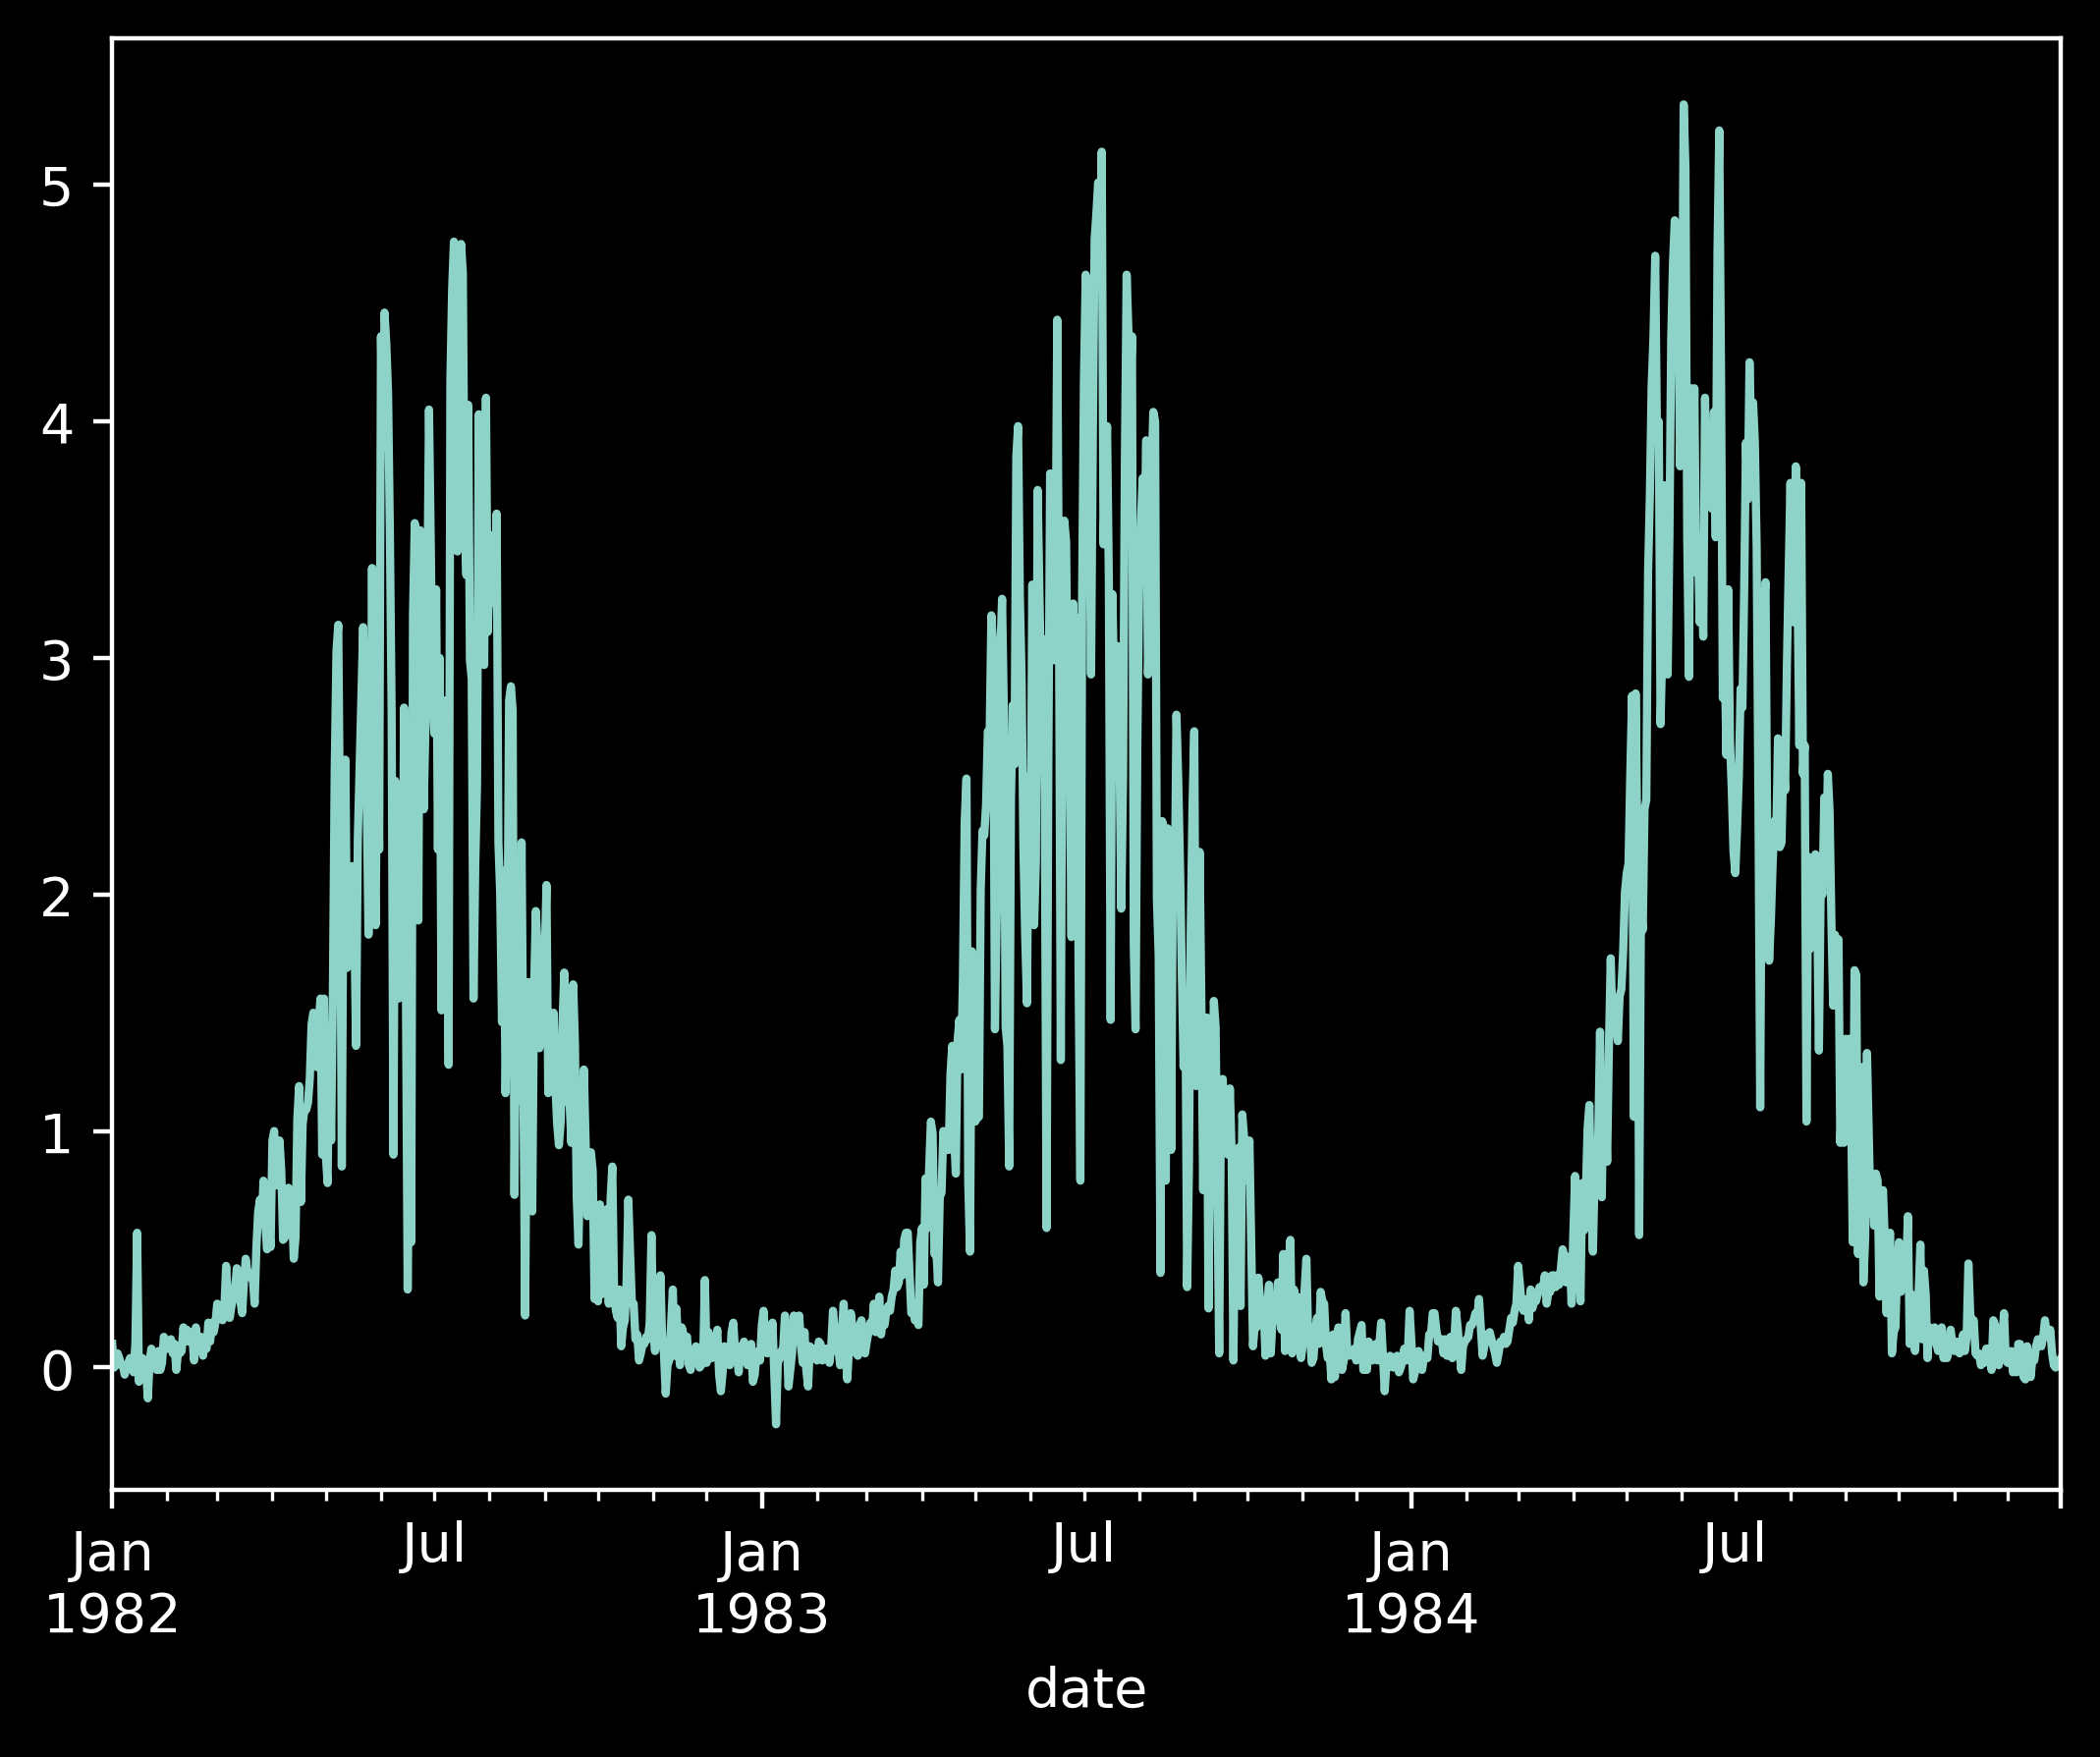

In [39]:
pet_singer.loc['1982':'1984', '896'].plot()

In [42]:
snow_e

,896,905,907,908,923,924,929,930,931,933,...,3602,3605,3607,3678,3719,3727,3728,3850,3907,3975
date,,,,,,,,,,,,,,,,,,,,,
1961-01-01,0.05,0.03,0.01,0.01,0.02,0.03,0.00,0.02,0.02,0.02,...,0.01,0.03,0.03,0.01,0.00,0.09,0.08,-0.00,0.02,0.02
1961-01-02,0.13,0.07,0.08,0.08,0.06,0.07,0.07,0.05,0.05,0.06,...,0.06,-0.00,-0.01,-0.05,-0.07,0.06,0.06,0.09,-0.03,0.04
1961-01-03,0.04,0.08,0.10,0.09,0.07,0.06,0.05,0.08,0.08,0.10,...,0.08,0.11,0.10,0.14,0.12,0.03,0.03,0.03,0.12,0.05
1961-01-04,0.11,0.10,0.12,0.12,0.10,0.10,0.09,0.17,0.16,0.15,...,0.13,0.12,0.27,0.21,0.19,0.22,0.23,0.06,0.19,0.08
1961-01-05,-0.00,0.05,0.06,0.06,0.02,0.02,0.02,0.07,0.08,0.08,...,0.03,-0.04,0.09,-0.01,-0.03,0.09,0.09,0.02,-0.02,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,-0.02,-0.01,-0.01,-0.01,-0.02,-0.02,-0.02,-0.01,-0.01,-0.01,...,-0.01,-0.01,-0.01,0.00,-0.08,-0.01,-0.01,-0.01,0.05,-0.00
2023-12-28,-0.01,-0.01,-0.01,-0.01,-0.01,-0.02,-0.03,0.01,0.01,-0.01,...,-0.01,-0.05,-0.02,0.01,-0.04,-0.01,-0.01,-0.04,0.01,-0.02
2023-12-29,0.01,-0.01,-0.01,-0.01,-0.01,-0.02,-0.02,0.00,-0.00,-0.01,...,0.03,0.13,0.14,0.12,0.07,-0.01,-0.01,0.03,0.10,0.08


In [11]:
snow_e = snow_e.loc["1981-01-01":"2023-12-31"]
snow_depth = snow_depth.loc["1981-01-01":"2023-12-31"]
new_index = pd.date_range(start="1981-01-01", end="2023-12-31", freq='D')
pet_fmi = pet_fmi.reindex(new_index)

<Axes: >

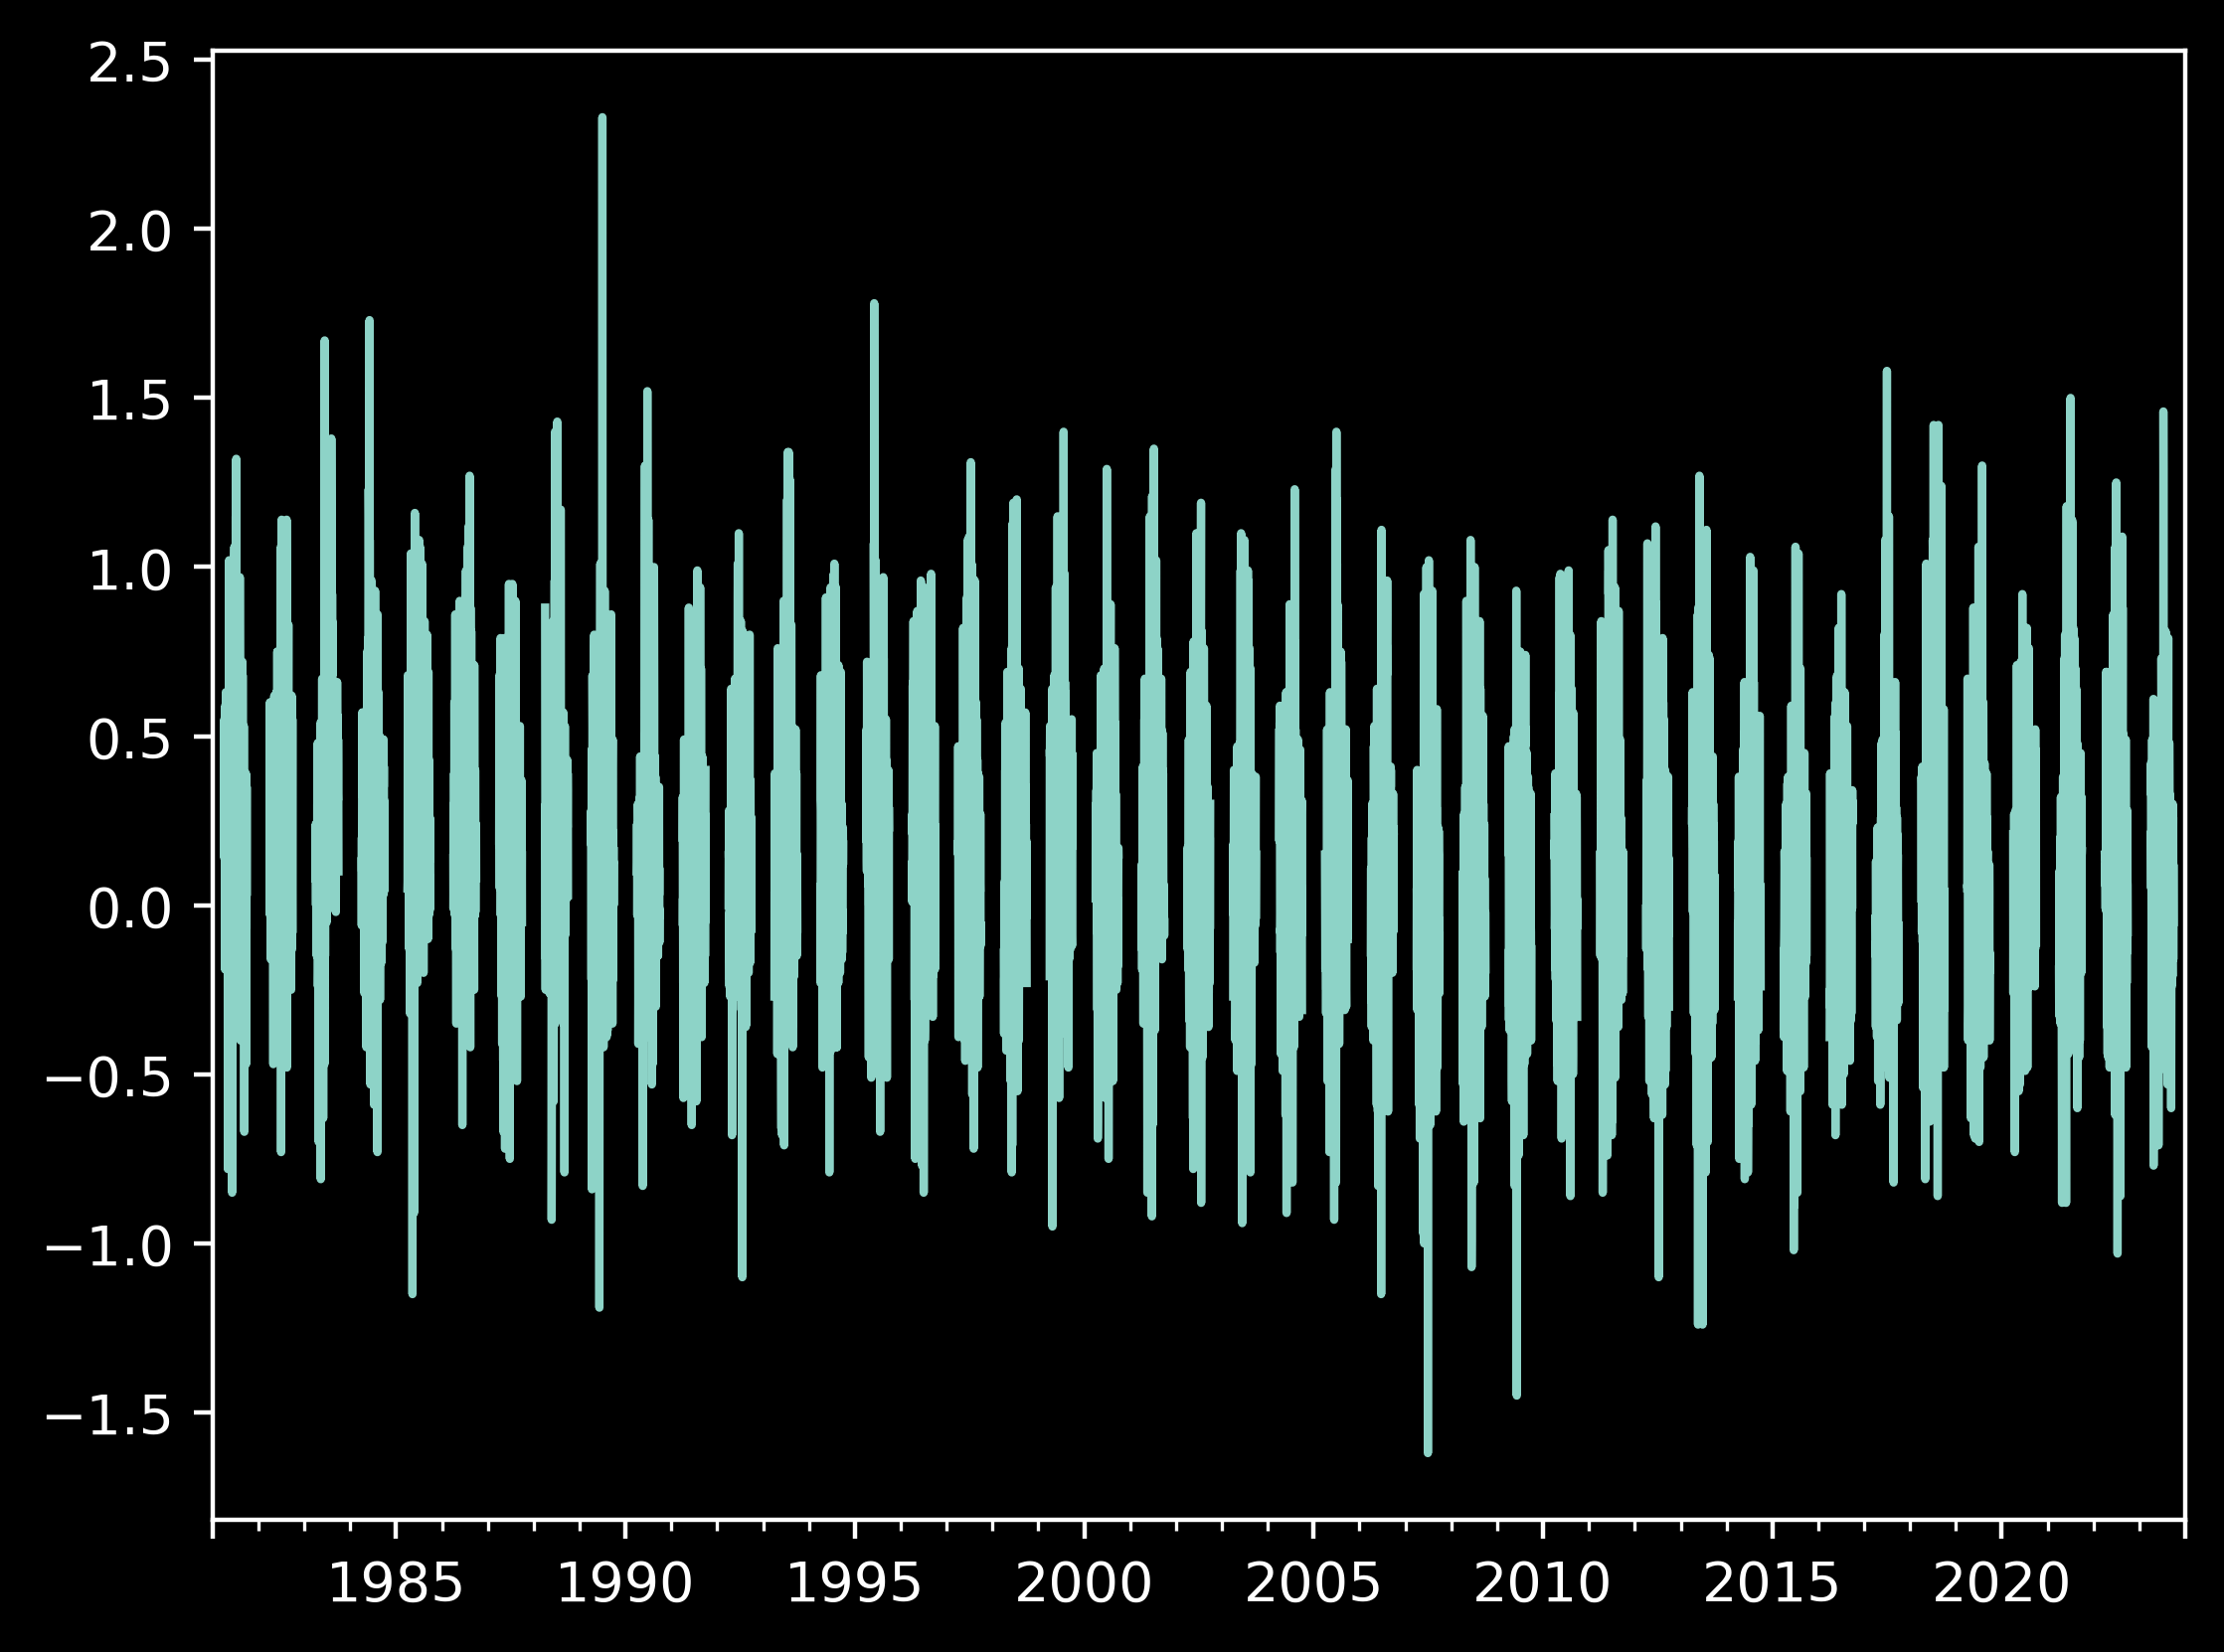

In [17]:
(pet_fmi['1117'] - pet_singer['1117']).plot()

In [29]:
pet =  pet_fmi.where(snow_depth < 1, snow_e)
pet = pet.fillna(pet_singer)

In [86]:
pet.to_csv('/media/iielse/T9/CAMELS-FI/data/timeseries-by-attribute/pet.csv')

In [19]:
timeseries_root = '/media/iielse/T9/CAMELS-FI/data/timeseries'
pattern='*.csv'

timeseries_files = glob(pattern, root_dir=camels_root) 

In [47]:
for file in timeseries_files:
    gauge = file.split('_')[4]
    path = os.path.join(timeseries_root, file)
    gauge_timeseries = read_daily_timeseries_csv(path)
    gauge_timeseries['pet'] = pet[gauge]
    gauge_timeseries.insert(6, 'pet_singer',pet_singer[gauge])
    gauge_timeseries = gauge_timeseries.drop('pe_era5_land', axis=1)
    gauge_timeseries.to_csv(path)


In [24]:
gauge_timeseries

,discharge_vol,discharge_spec,precipitation,pet,pe_era5_land,pet_fmi,snow_evaporation,swe,swe_cci3-1,snow_depth,temperature_gmin,temperature_min,temperature_mean,temperature_max,humidity_rel,radiation_global
date,,,,,,,,,,,,,,,,
1961-01-01,35.00,0.52,3.6,NaN,0.06,NaN,0.01,67.97,NaN,25.4,-5.9,-5.5,-3.9,-3.6,96.0,284.8
1961-01-02,35.00,0.52,1.9,NaN,0.20,NaN,0.04,71.46,NaN,28.6,-5.3,-4.3,-3.4,-2.9,94.7,296.8
1961-01-03,35.00,0.52,0.9,NaN,0.54,NaN,0.07,72.80,NaN,29.8,-4.5,-3.8,-2.8,-1.8,95.4,307.6
1961-01-04,35.00,0.52,4.5,NaN,1.38,NaN,0.15,74.03,NaN,30.7,-4.6,-4.3,-2.4,-2.0,92.2,318.1
1961-01-05,35.00,0.52,2.6,NaN,1.91,NaN,0.04,78.02,NaN,33.2,-3.4,-3.0,-0.5,0.9,96.5,331.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,77.91,1.17,0.6,-0.02,0.01,NaN,-0.02,88.44,NaN,46.9,NaN,-12.8,-9.9,-7.9,92.1,277.7
2023-12-28,77.25,1.16,0.0,-0.01,-0.03,NaN,-0.01,89.12,NaN,47.0,NaN,-8.3,-6.6,-5.9,94.4,193.7
2023-12-29,76.43,1.15,0.0,0.02,0.18,NaN,0.02,89.31,NaN,45.3,NaN,-12.0,-8.7,-5.8,92.3,244.2


<Axes: >

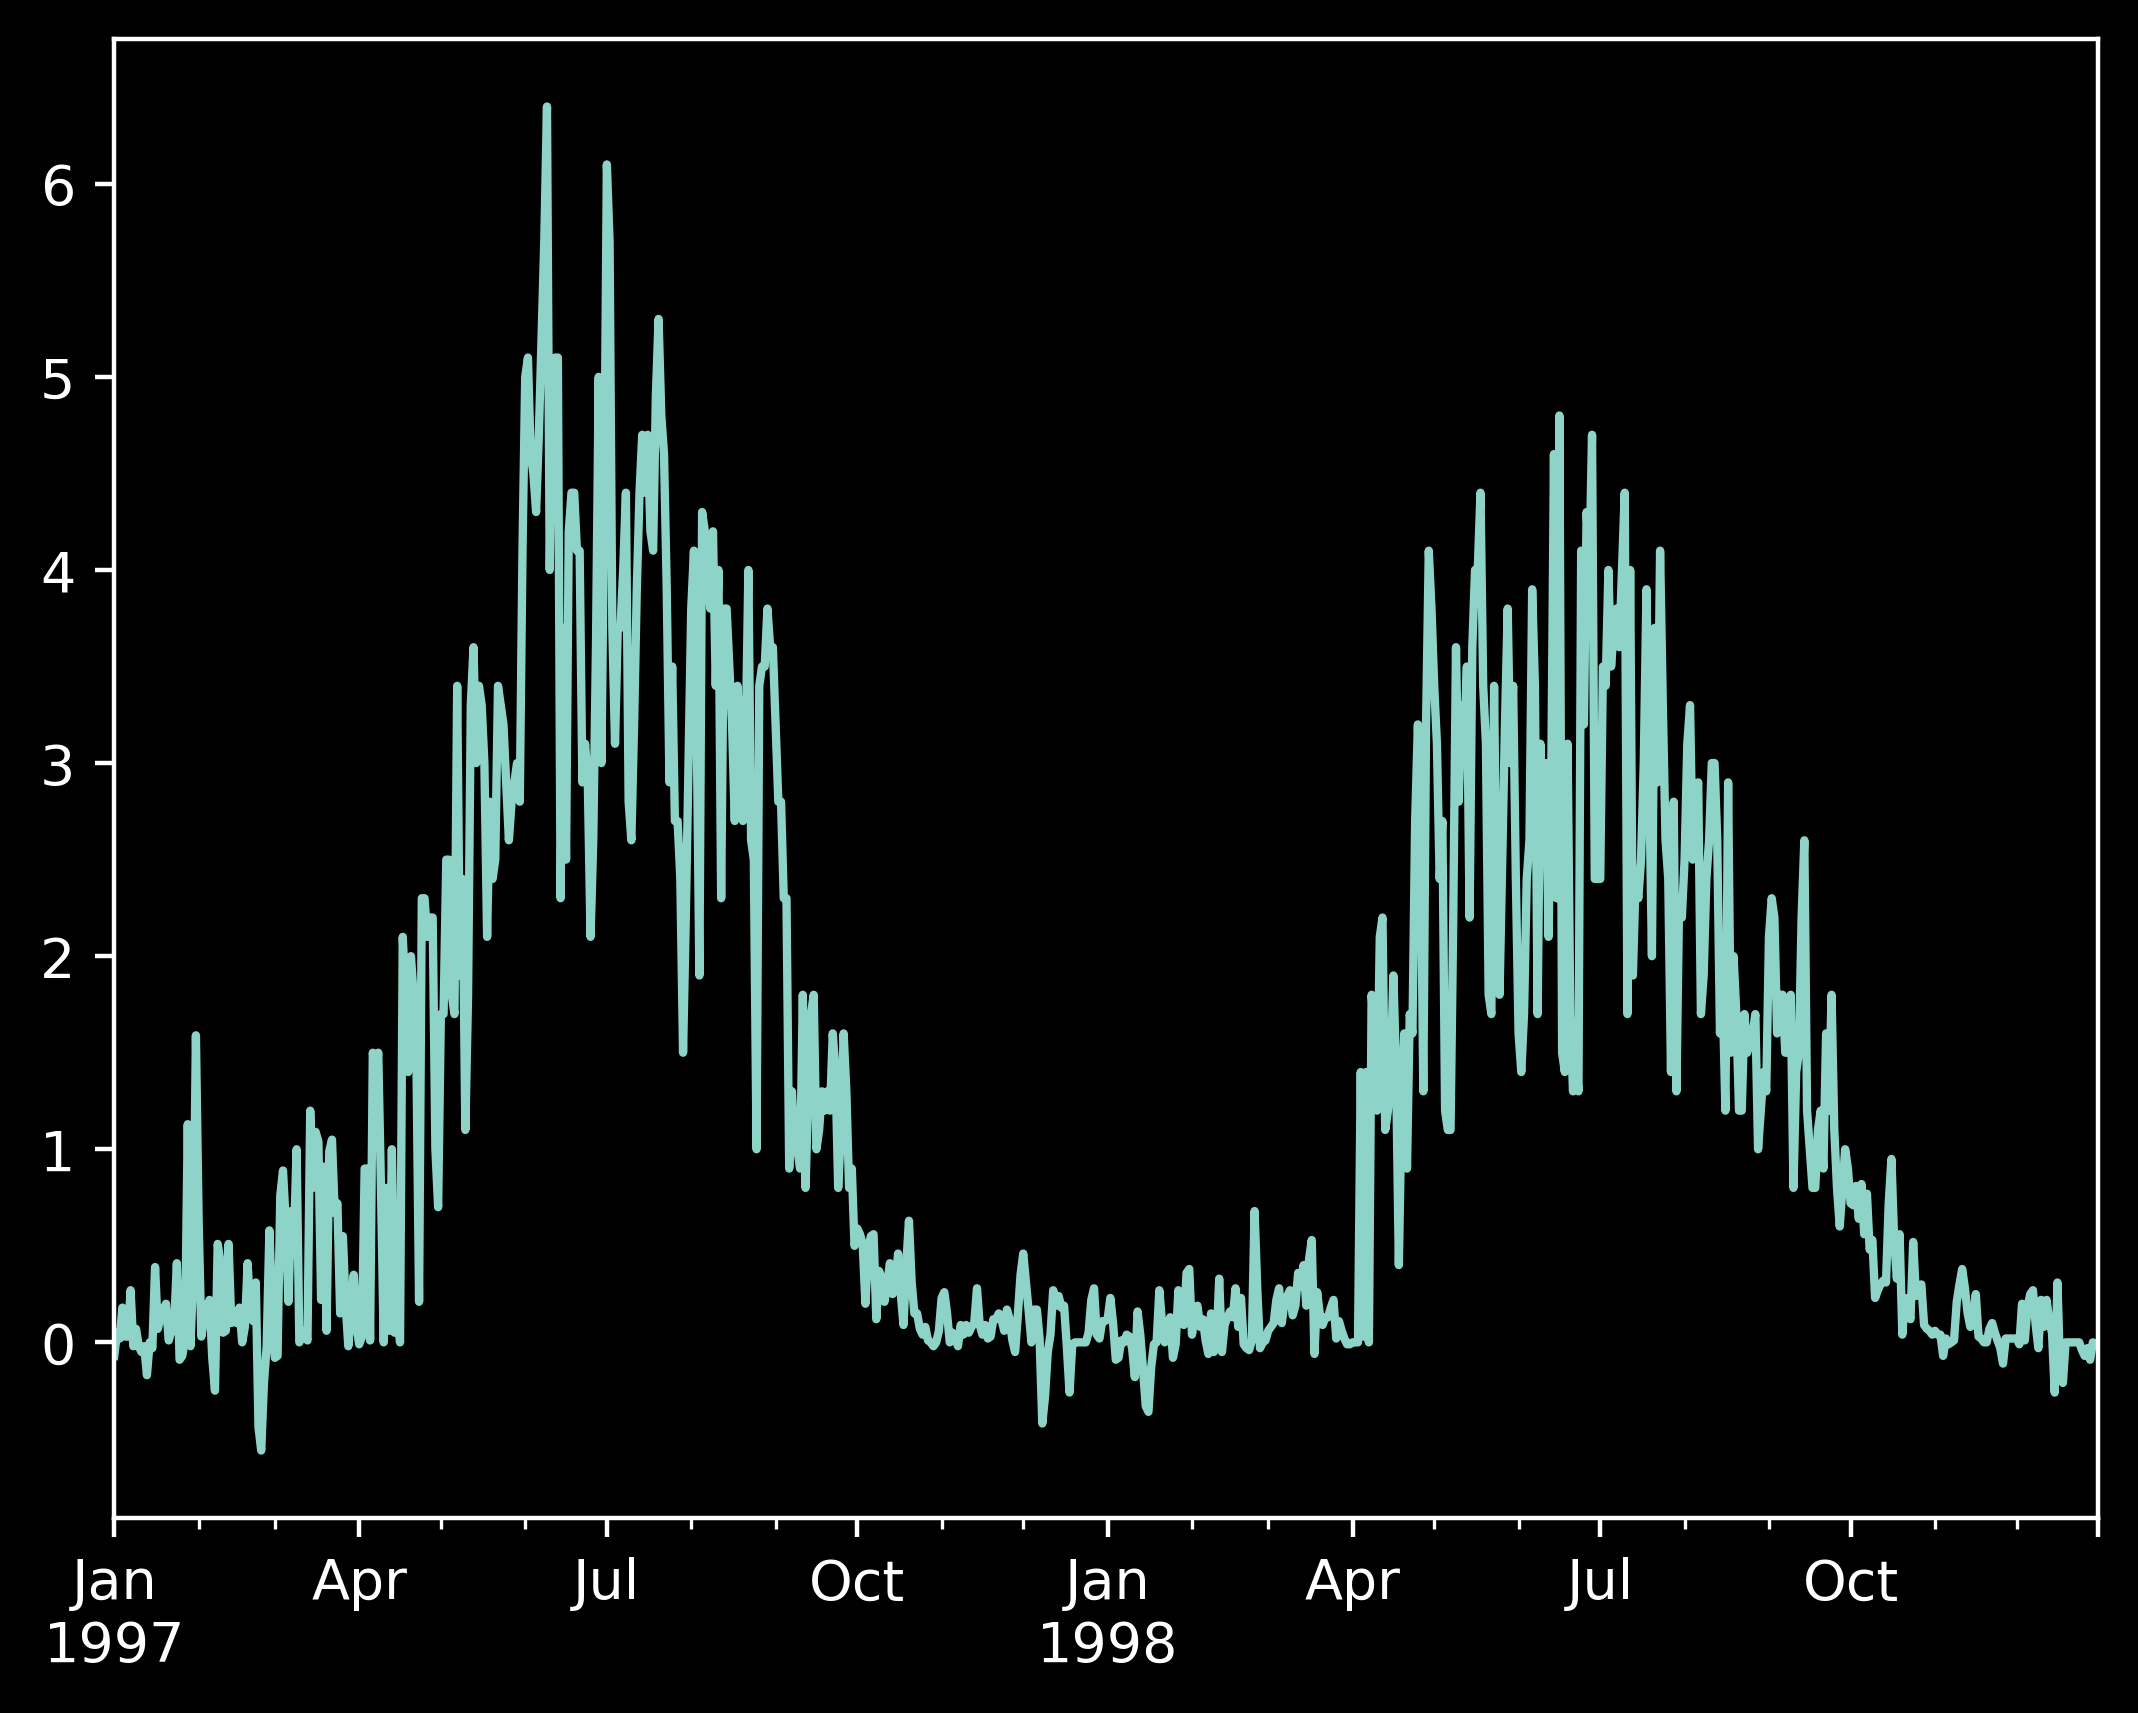

In [85]:
pet.loc["1997":"1998", '1117'].plot()

<Axes: xlabel='date'>

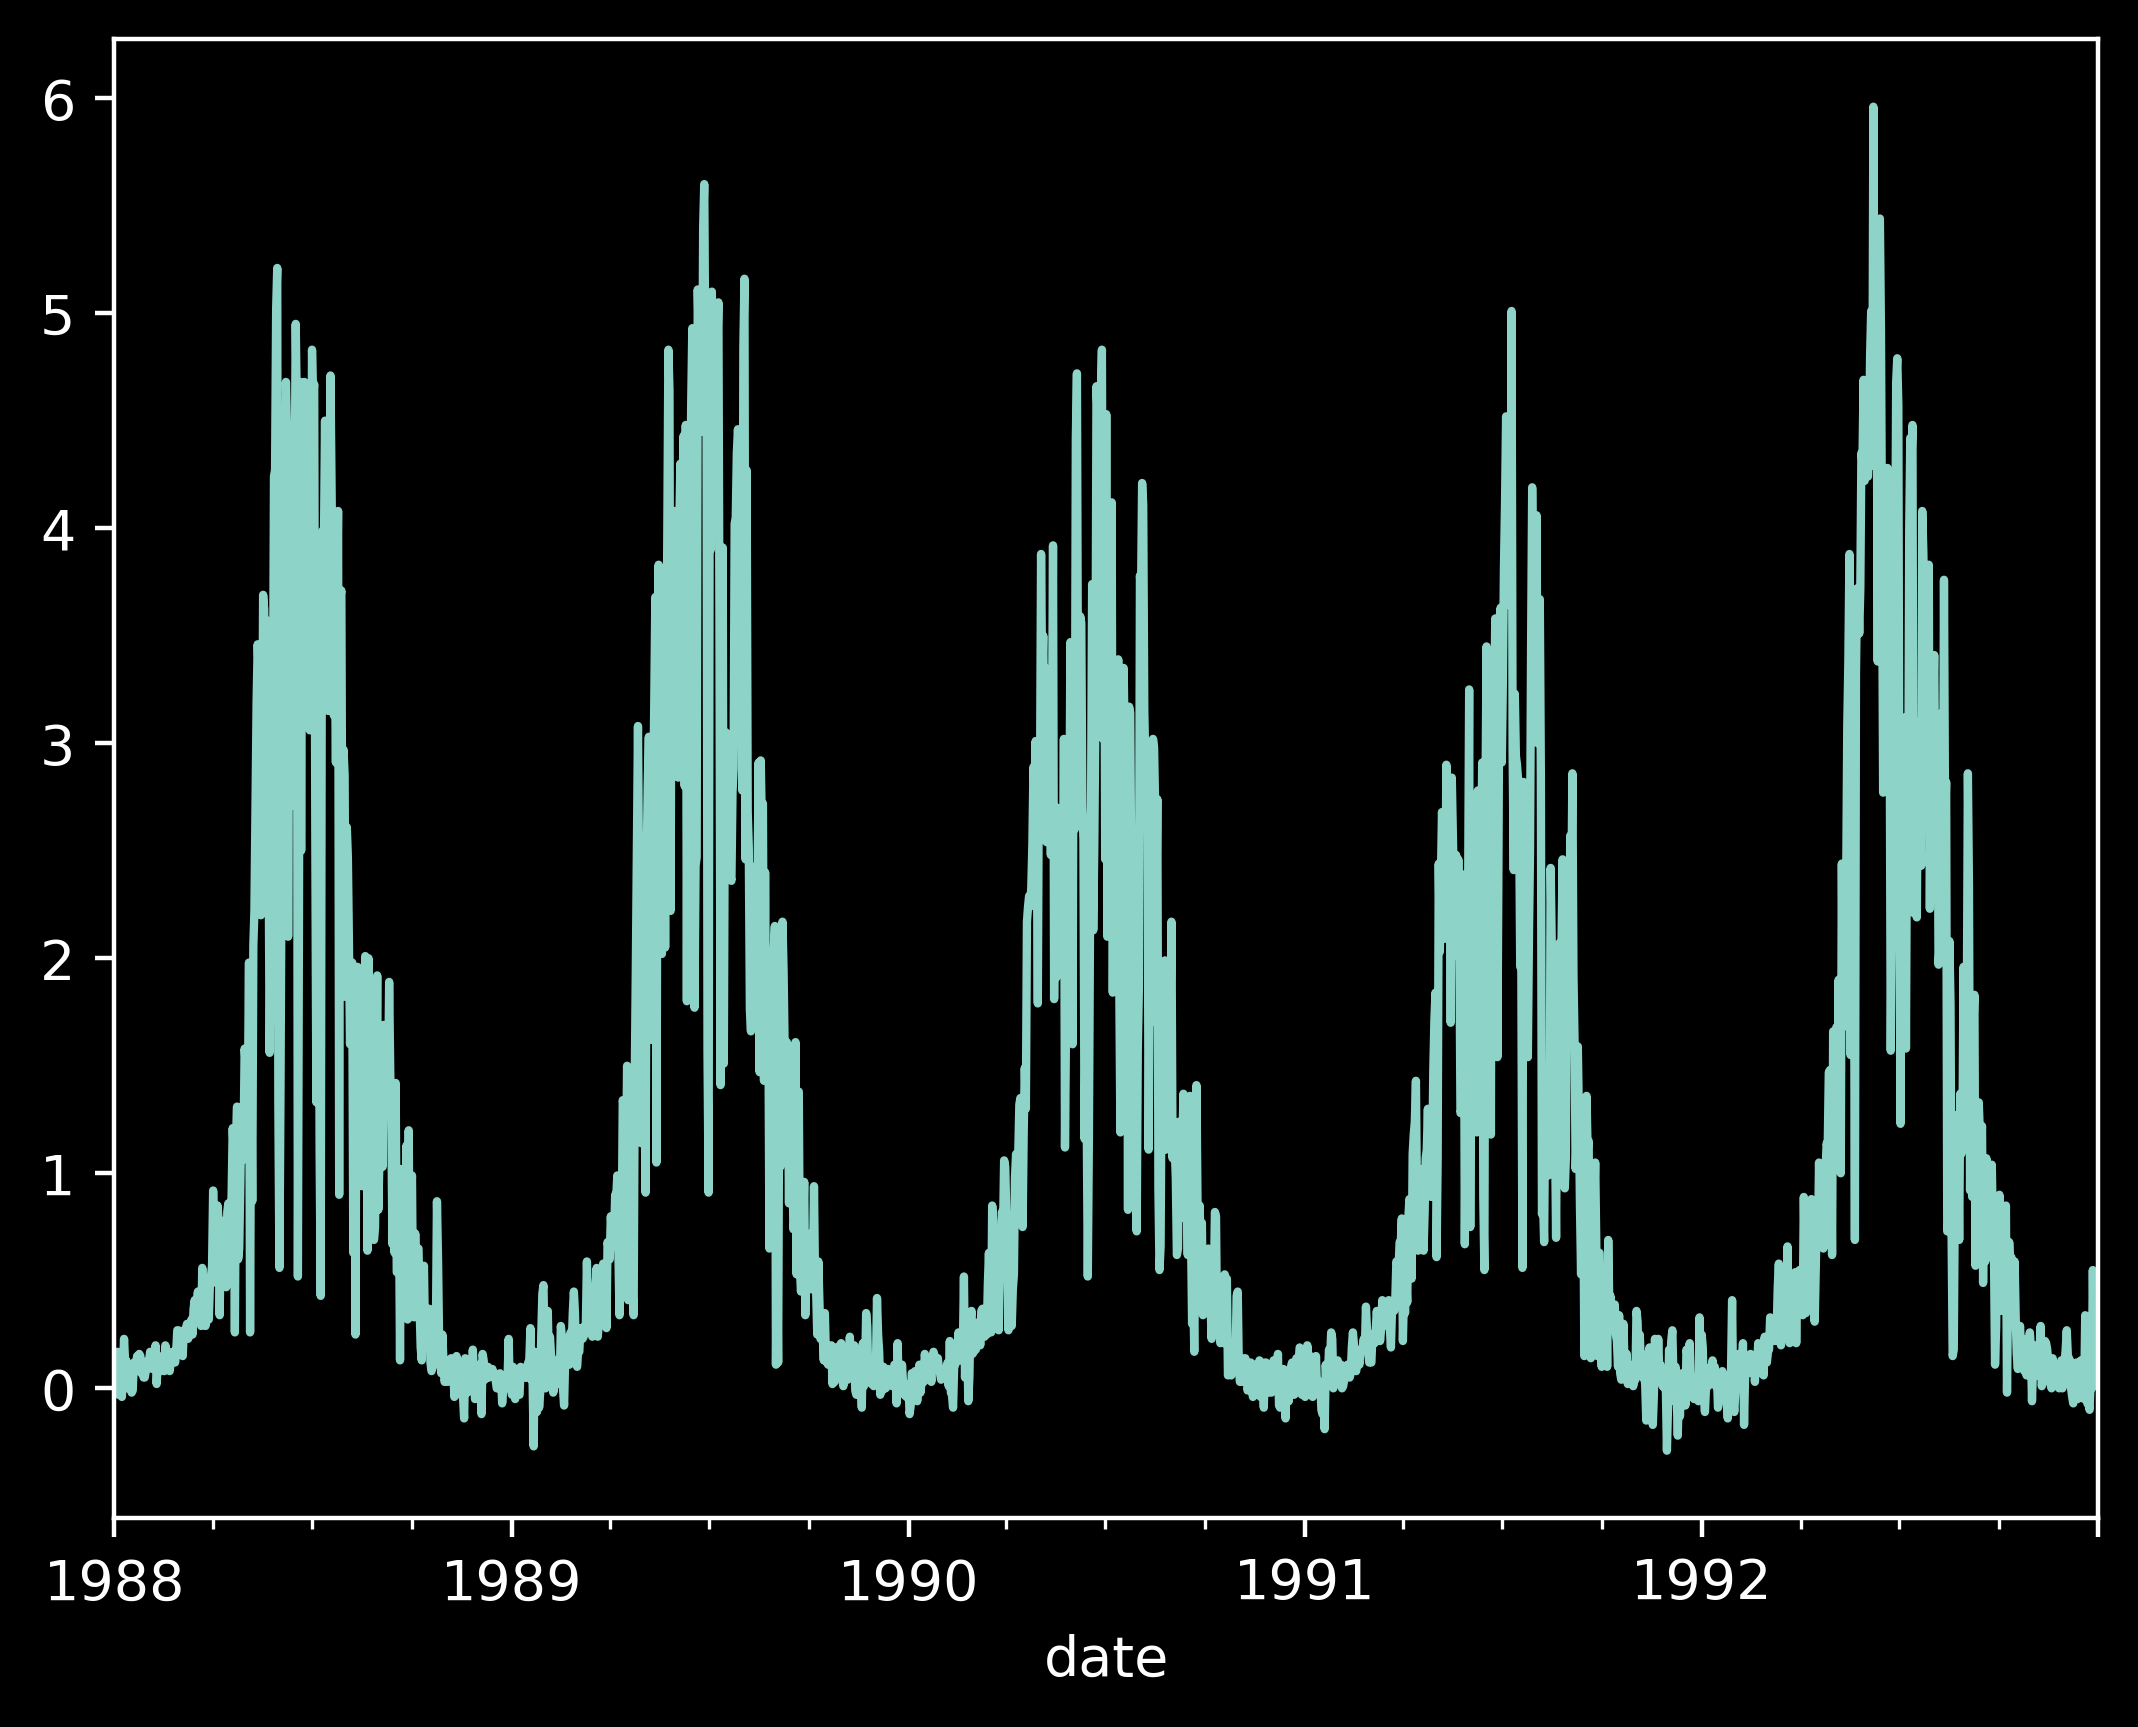

In [71]:
pet_singer.loc["1988":"1992", '896'].plot()

<Axes: xlabel='date'>

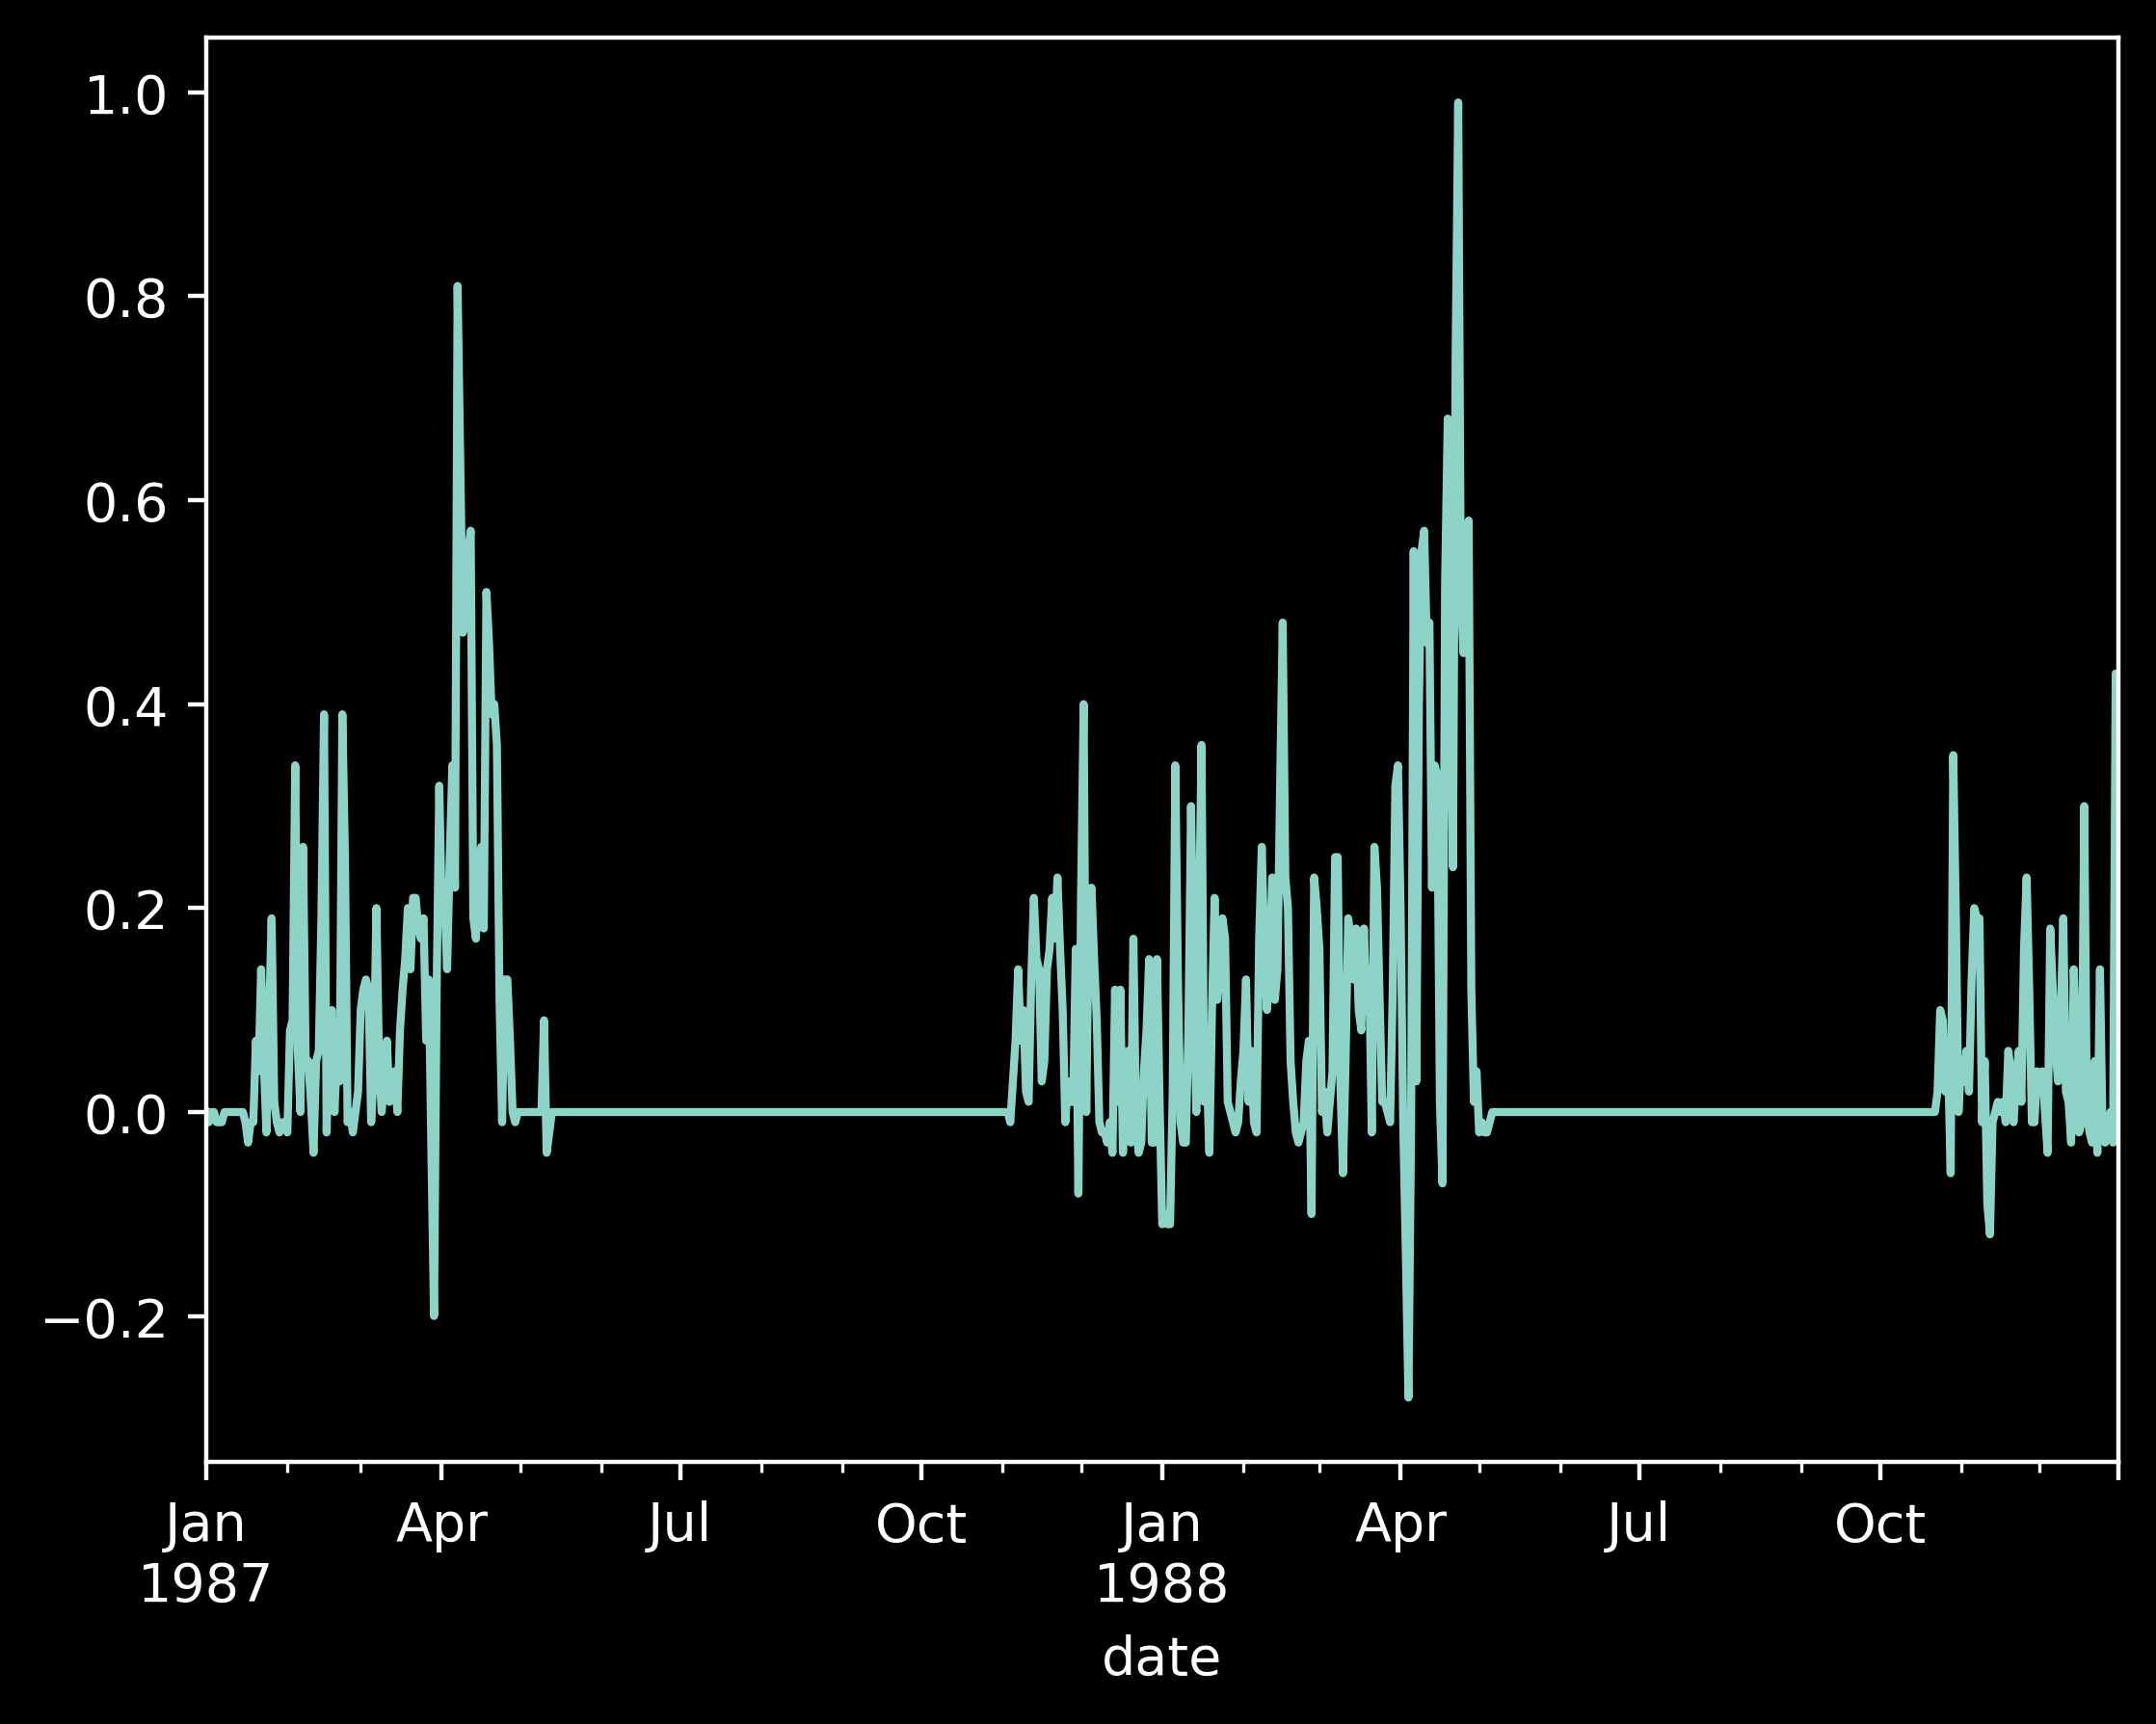

In [69]:
snow_e.loc["1987":"1988", '896'].plot()

<Axes: >

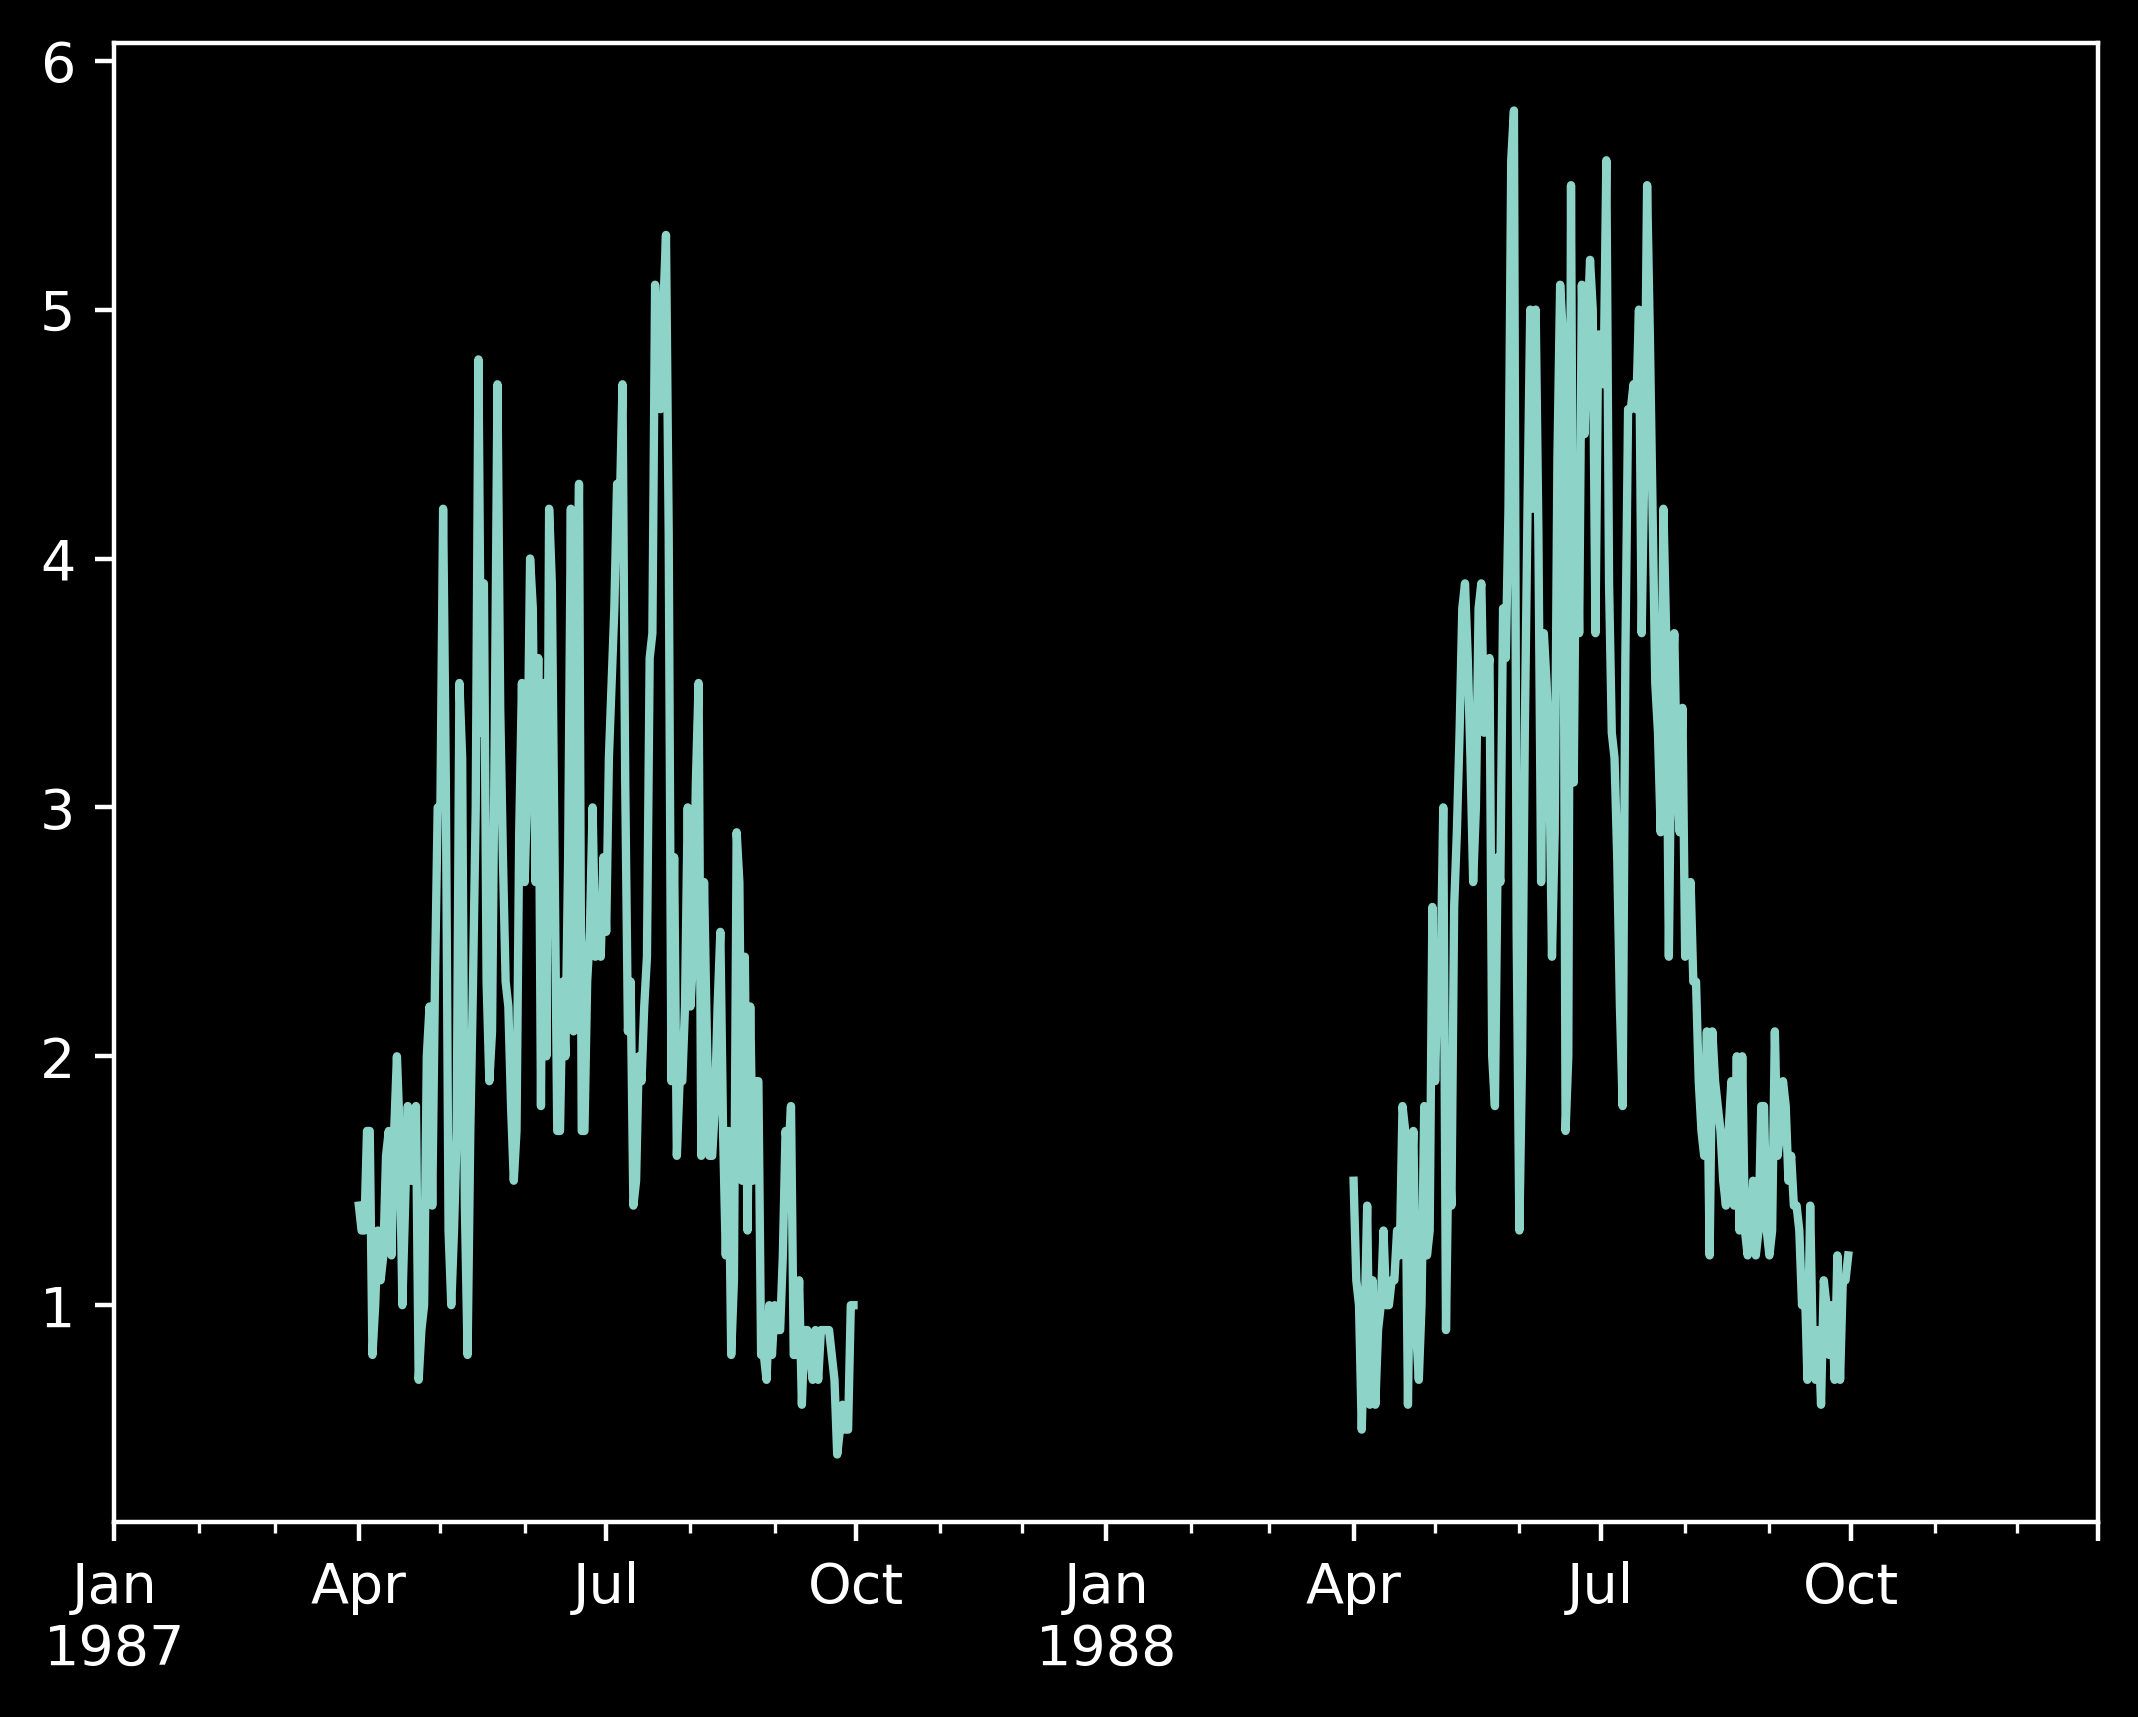

In [87]:
pet_fmi.loc["1987":"1988", '896'].plot()

In [93]:
clim = pd.read_csv('/media/iielse/T9/CAMELS-FI/data/CAMELS_FI_climatic_attributes.csv', index_col='gauge_id')
clim

,p_mean,pet_mean,temperature_mean,aridity,p_seasonality,frac_snow,high_prec_freq,high_prec_dur,high_prec_timing,low_prec_freq,low_prec_dur,low_prec_timing
gauge_id,,,,,,,,,,,,
896,1.85,1.52,3.62,0.82,0.23,0.27,15.70,1.16,jja,229.02,3.92,mam
905,1.98,1.29,2.54,0.65,0.23,0.30,14.43,1.15,jja,221.29,3.56,mam
907,1.84,1.25,2.62,0.68,0.28,0.29,15.67,1.14,jja,228.12,3.81,mam
908,1.81,1.25,2.66,0.69,0.27,0.29,15.43,1.12,jja,229.16,3.86,mam
923,1.97,1.42,2.97,0.72,0.22,0.30,15.17,1.10,jja,220.36,3.71,mam
...,...,...,...,...,...,...,...,...,...,...,...,...
3727,1.70,1.15,1.30,0.68,0.27,0.34,16.20,1.15,jja,235.29,3.90,mam
3728,1.69,1.14,1.28,0.67,0.27,0.34,16.57,1.15,jja,236.59,3.94,mam
3850,1.75,1.88,4.74,1.08,0.20,0.24,16.63,1.20,jja,237.36,4.21,NaN


In [96]:
pet_mean =  pet["1990-09-01":"2020-08-31"].mean()
aridity = pet_mean / clim['p_mean']

In [101]:
(pet_mean - clim['pet_mean']).mean()

np.float64(-0.33096567576200037)

<Axes: >

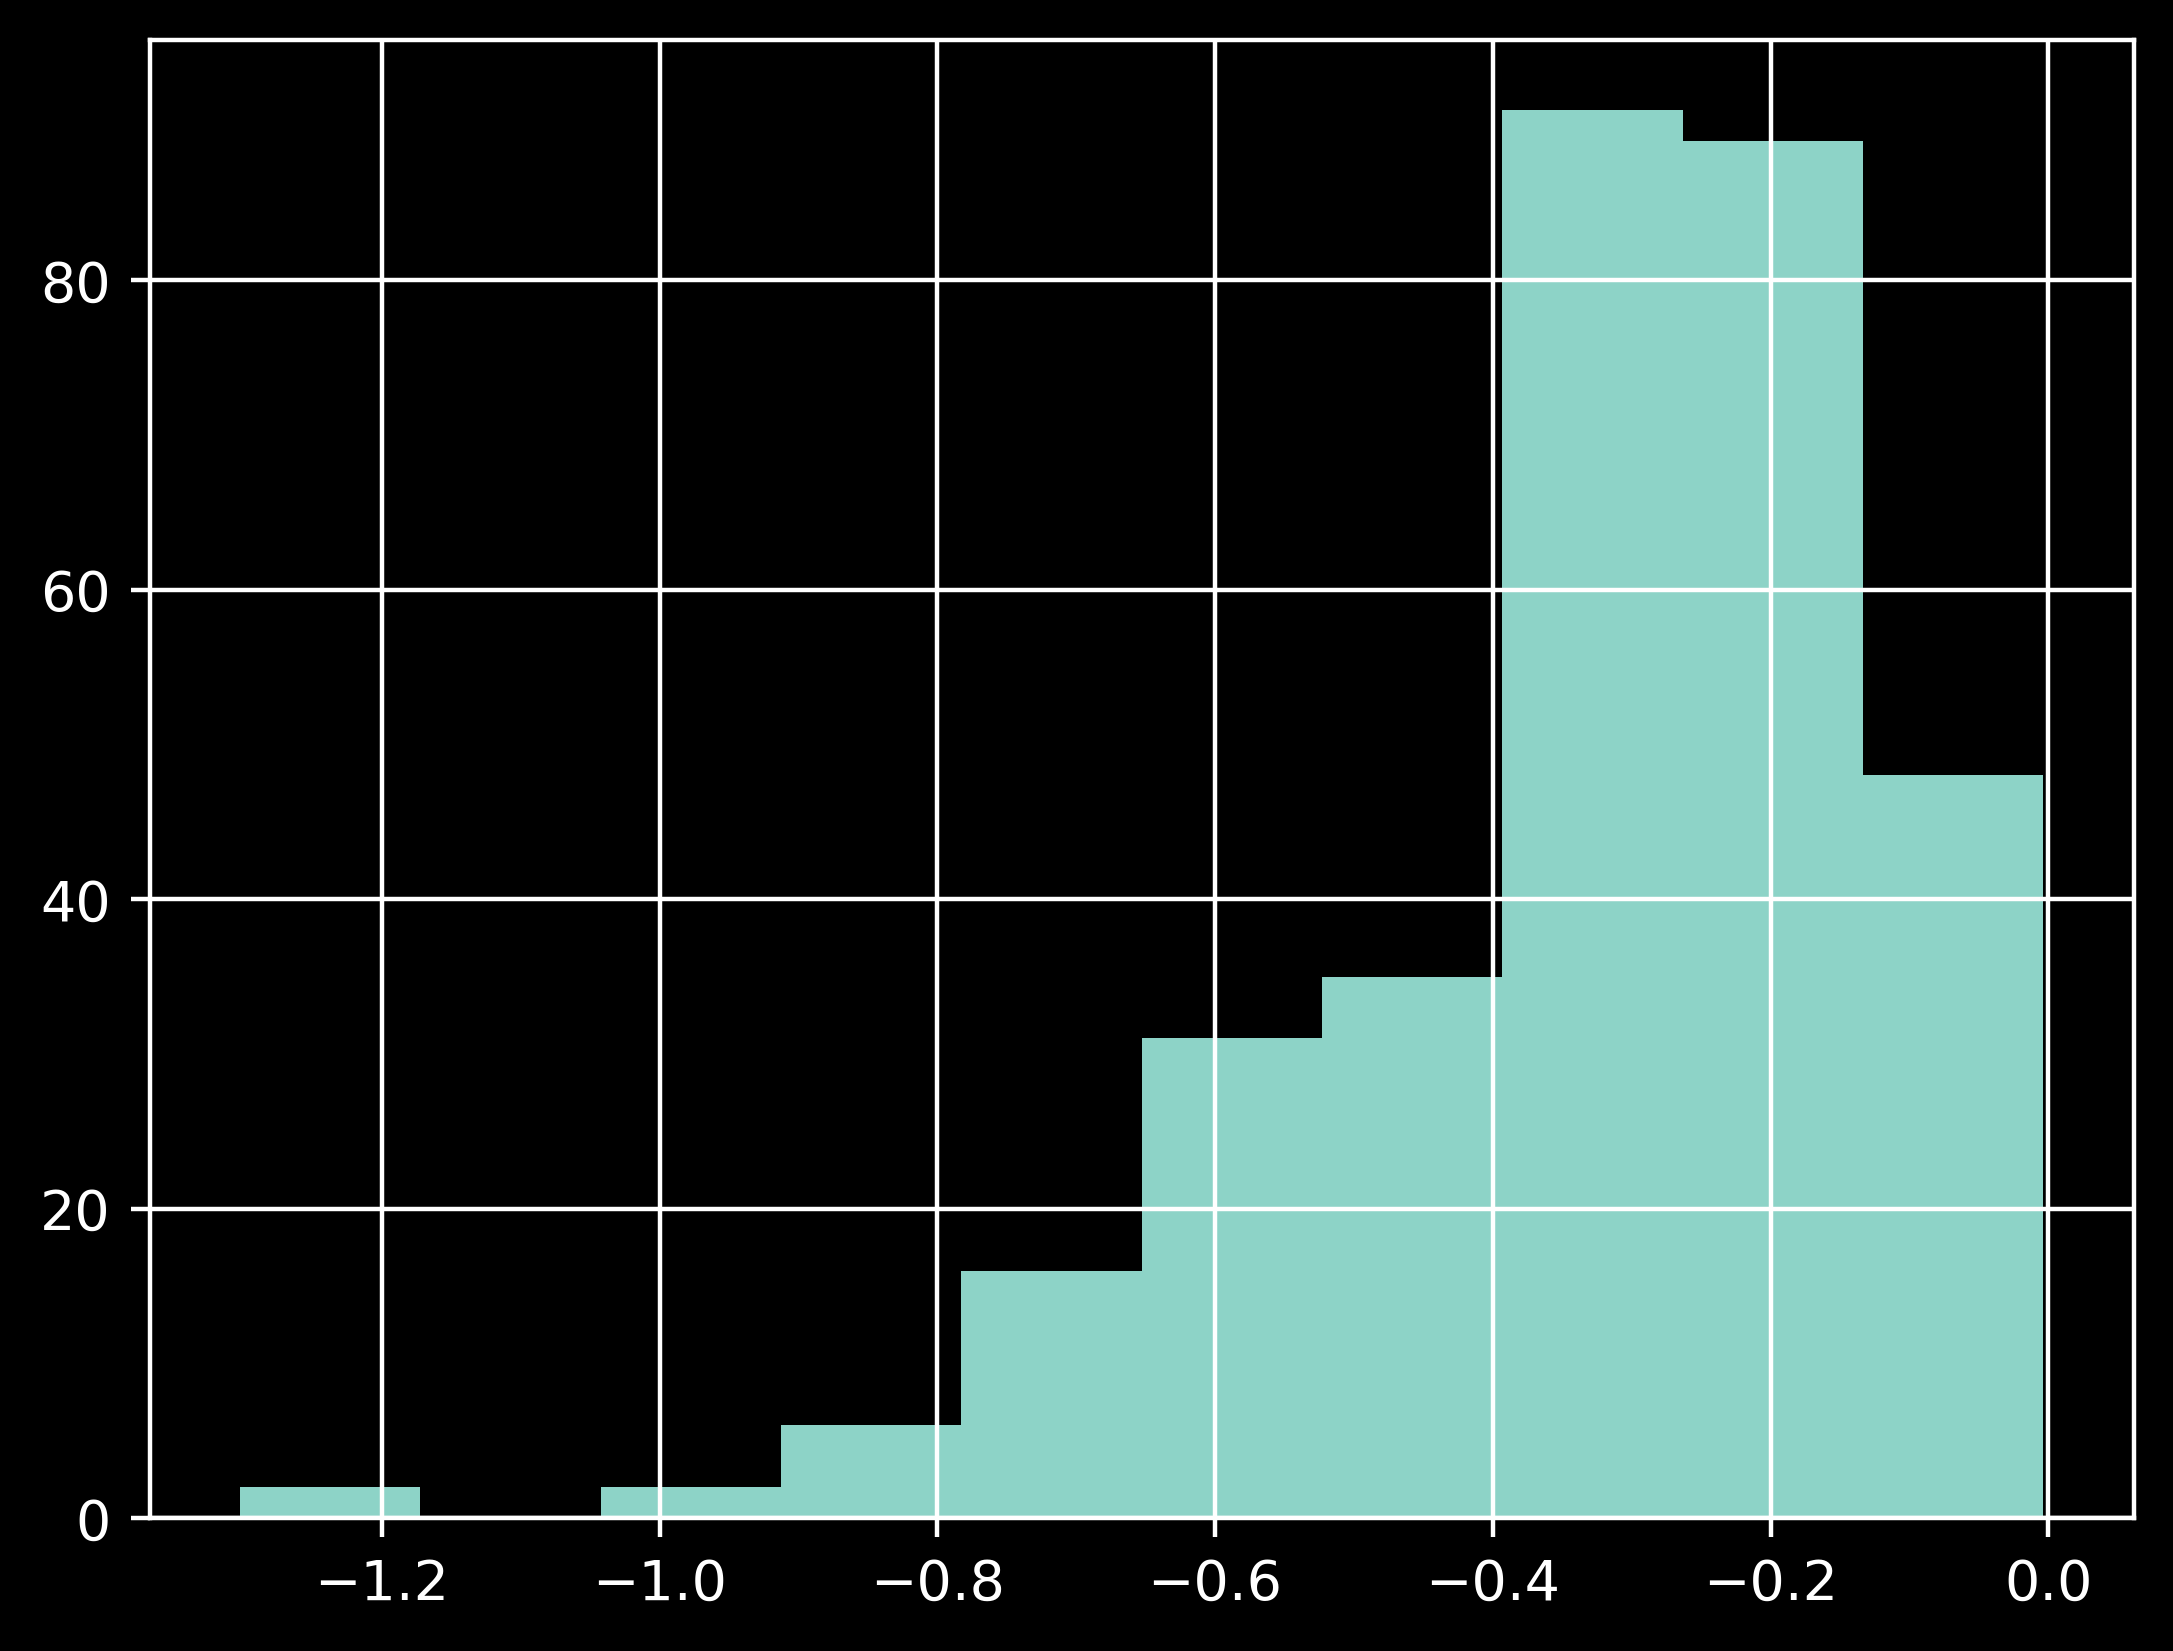

In [98]:
(pet_mean - clim['pet_mean']).hist()

In [102]:
(aridity - clim['aridity']).mean()

np.float64(-0.19121619330412215)

<Axes: >

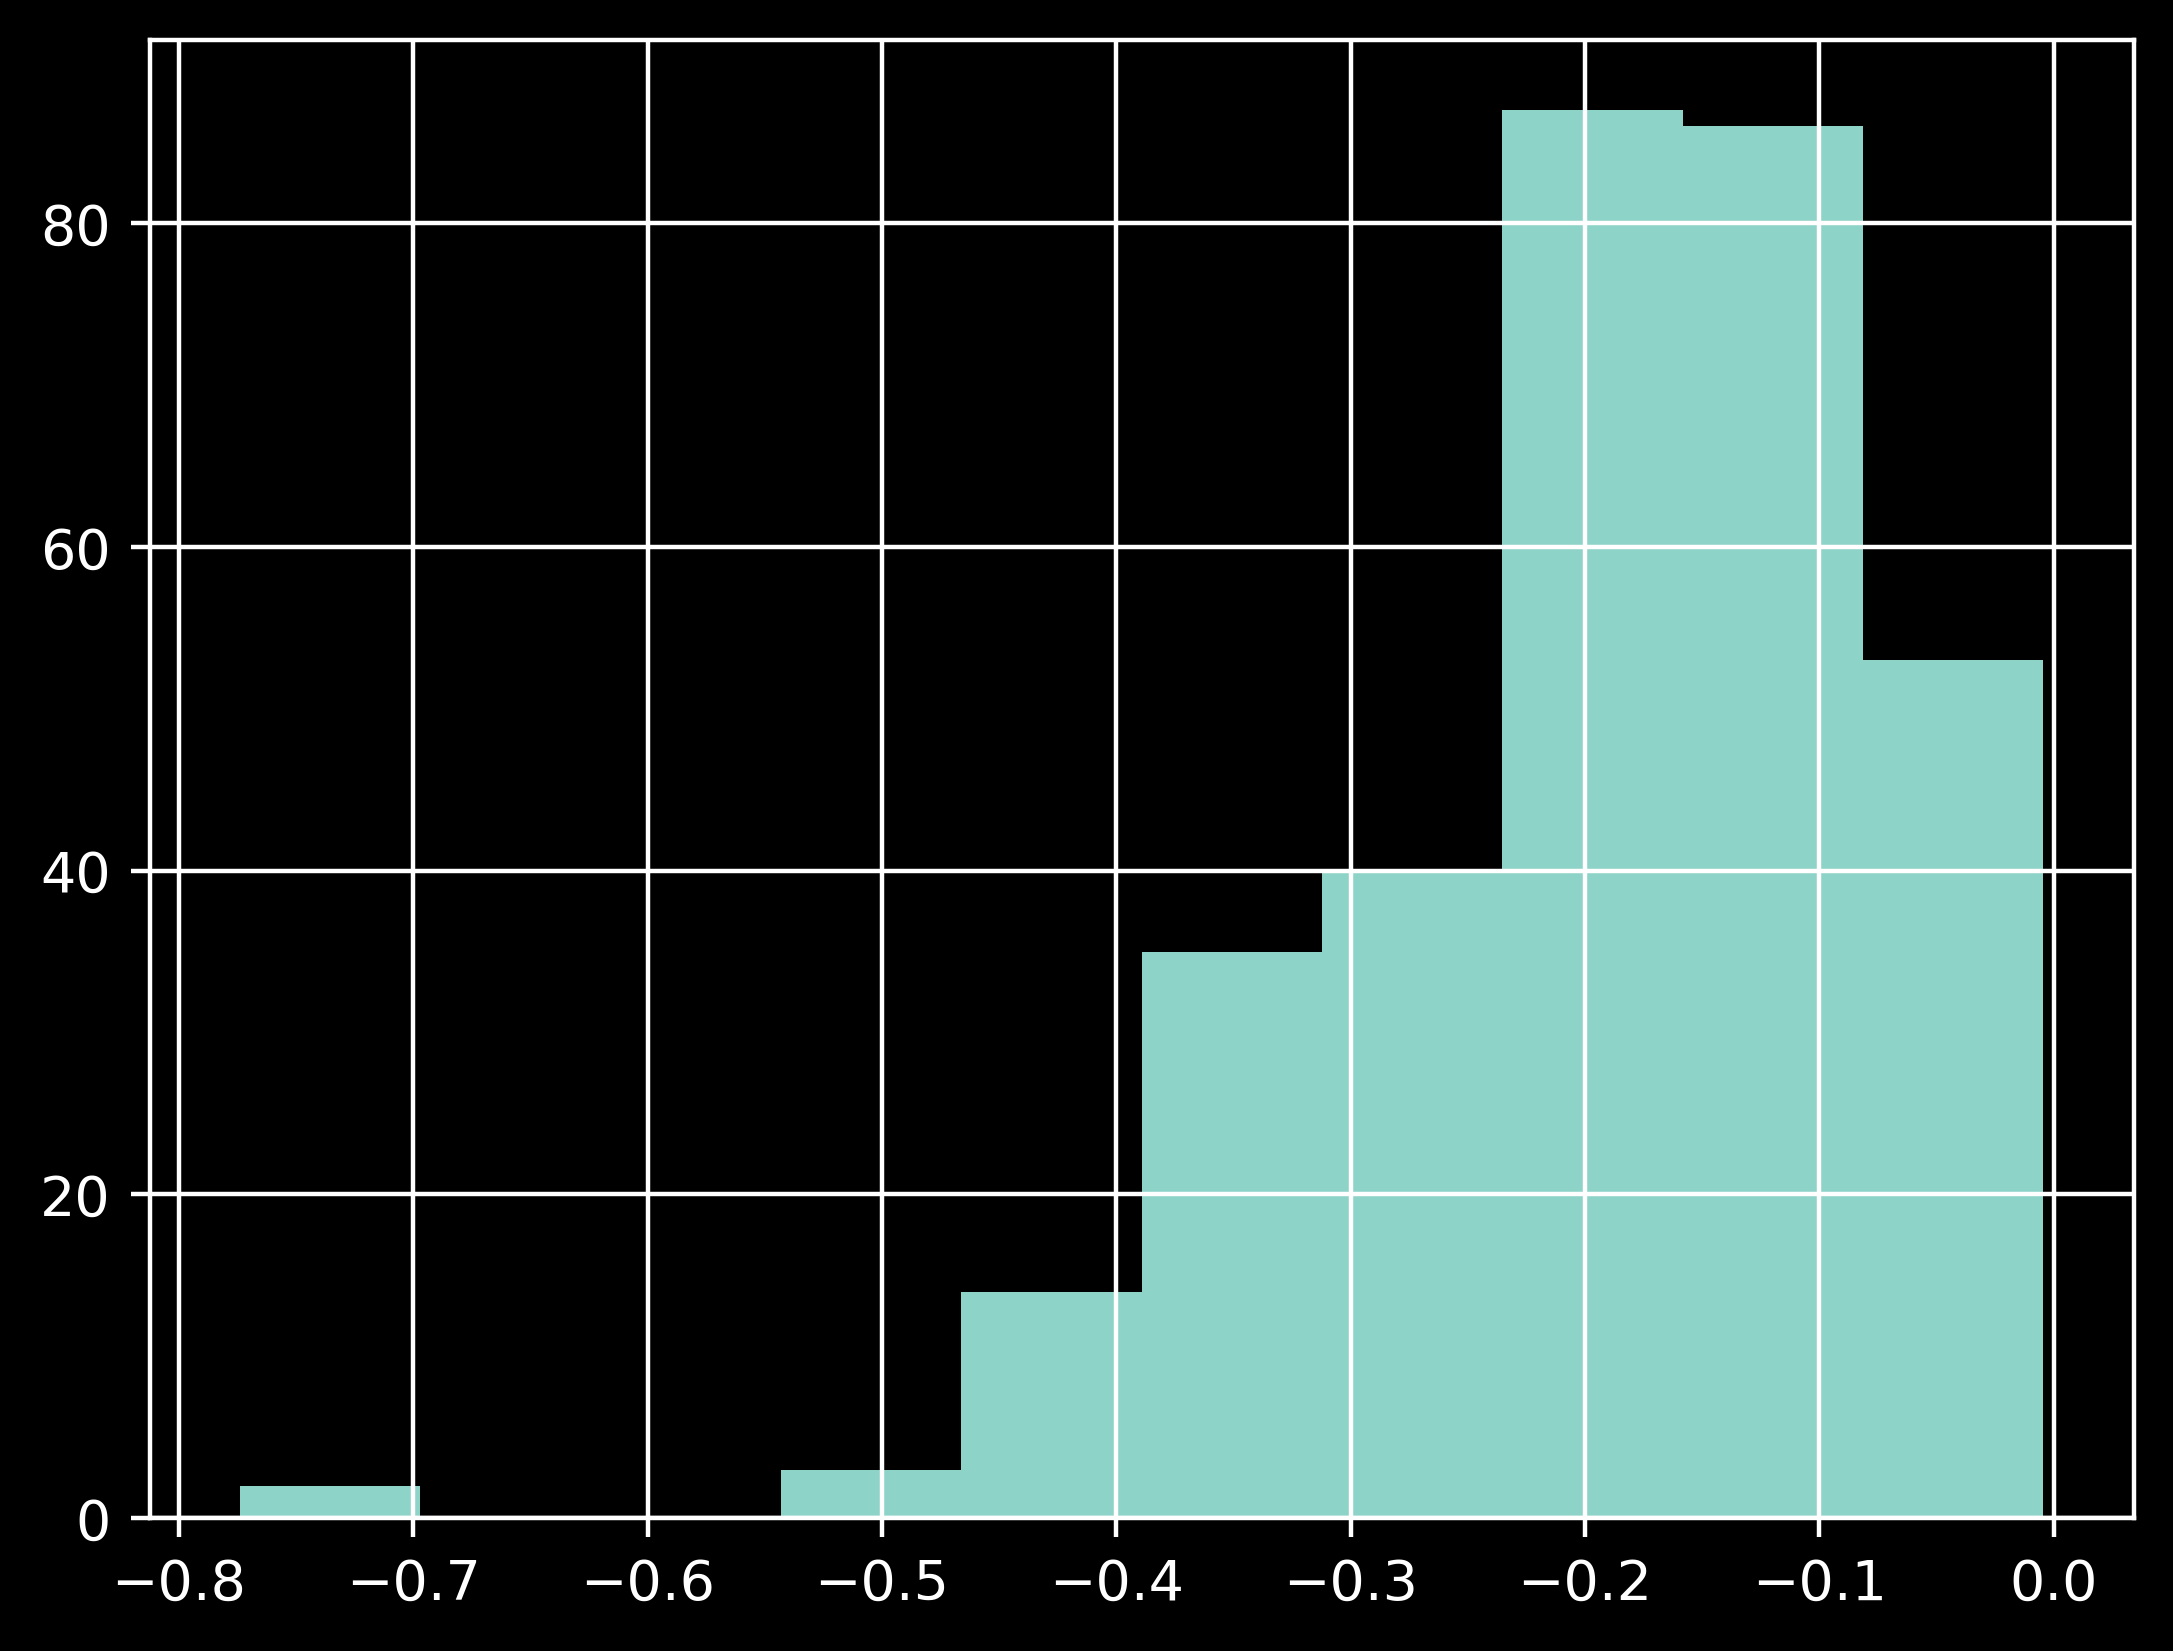

In [100]:
(aridity - clim['aridity']).hist()

In [106]:
clim['aridity'] = aridity

In [104]:
clim['pet_mean'] = pet_mean

In [107]:
clim

,p_mean,pet_mean,temperature_mean,aridity,p_seasonality,frac_snow,high_prec_freq,high_prec_dur,high_prec_timing,low_prec_freq,low_prec_dur,low_prec_timing
gauge_id,,,,,,,,,,,,
896,1.85,1.174532,3.62,0.634882,0.23,0.27,15.70,1.16,jja,229.02,3.92,mam
905,1.98,1.036260,2.54,0.523364,0.23,0.30,14.43,1.15,jja,221.29,3.56,mam
907,1.84,1.066285,2.62,0.579503,0.28,0.29,15.67,1.14,jja,228.12,3.81,mam
908,1.81,1.058901,2.66,0.585028,0.27,0.29,15.43,1.12,jja,229.16,3.86,mam
923,1.97,1.087236,2.97,0.551896,0.22,0.30,15.17,1.10,jja,220.36,3.71,mam
...,...,...,...,...,...,...,...,...,...,...,...,...
3727,1.70,0.993126,1.30,0.584192,0.27,0.34,16.20,1.15,jja,235.29,3.90,mam
3728,1.69,0.992131,1.28,0.587060,0.27,0.34,16.57,1.15,jja,236.59,3.94,mam
3850,1.75,1.341237,4.74,0.766421,0.20,0.24,16.63,1.20,jja,237.36,4.21,NaN


In [108]:
clim.to_csv('/media/iielse/T9/CAMELS-FI/data/CAMELS_FI_climatic_attributes.csv')